In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from ultralytics import YOLO

In [2]:
def best_edge_fix(img_path):
    # Read image
    img = img_path
    
    # Convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Improve contrast
    gray = cv2.equalizeHist(gray)

    # Remove noise but keep edges
    gray = cv2.bilateralFilter(gray, 9, 75, 75)

    # Morphological gradient
    kernel_grad = np.ones((5, 5), np.uint8)
    grad = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel_grad)

    return gray, grad

In [3]:

def rotate_mask(mask, angle, center):
    (h, w) = mask.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        mask,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderValue=0
    )
    return rotated


def get_mask_height(mask):
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return 0
    return ys.max() - ys.min()


def get_centroid(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return (mask.shape[1] // 2, mask.shape[0] // 2)
    return (int(xs.mean()), int(ys.mean()))


def get_orientation(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return 0

    coords = np.column_stack((xs, ys)).astype(np.float32)

    # PCA to get principal direction
    mean, eigenvectors = cv2.PCACompute(coords, mean=None)

    vx, vy = eigenvectors[0]

    angle = np.degrees(np.arctan2(vy, vx))
    return angle

def get_top_bottom_points(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None, None

    # Top row (minimum y)
    min_y = ys.min()
    top_xs = xs[ys == min_y]
    top_point = (int(top_xs.mean()), int(min_y))

    # Bottom row (maximum y)
    max_y = ys.max()
    bottom_xs = xs[ys == max_y]
    bottom_point = (int(bottom_xs.mean()), int(max_y))

    return top_point, bottom_point


def find_best_rotation(mask, center=None):
    if center is None:
        center = get_centroid(mask)

    # Step 1: get orientation
    angle = get_orientation(mask)

    # Step 2: rotate so object becomes vertical
    corrected_angle = angle - 90

    best_mask = rotate_mask(mask, corrected_angle, center)

    # Step 3: compute final height
    height = get_mask_height(best_mask)

    # Step 4: get top & bottom points
    top_point, bottom_point = get_top_bottom_points(best_mask)

    return best_mask, corrected_angle, height, (top_point, bottom_point),center

# Mask rotation 2

In [4]:
import cv2
import numpy as np


def rotate_mask(mask, angle, center=None):
    h, w = mask.shape[:2]

    # Use image center if not provided
    if center is None:
        center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        mask,
        M,
        (w, h),                     # keep same mask size
        flags=cv2.INTER_NEAREST,    # preserve mask labels
        borderValue=0
    )

    return rotated


def get_mask_height(mask):
    ys, xs = np.where(mask > 0)

    if len(ys) == 0:
        return 0

    return ys.max() - ys.min()


def get_orientation(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return 0

    coords = np.column_stack((xs, ys)).astype(np.float32)

    _, eigenvectors = cv2.PCACompute(
        coords,
        mean=None
    )

    vx, vy = eigenvectors[0]

    angle = np.degrees(
        np.arctan2(vy, vx)
    )

    return angle


def get_top_bottom_points(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None, None

    min_y = ys.min()
    max_y = ys.max()

    top_point = (
        int(xs[ys == min_y].mean()),
        int(min_y)
    )

    bottom_point = (
        int(xs[ys == max_y].mean()),
        int(max_y)
    )

    return top_point, bottom_point


def find_best_rotation(mask):

    h, w = mask.shape[:2]

    # image center
    center = (w // 2, h // 2)

    # PCA orientation
    angle = get_orientation(mask)

    # rotate to make vertical
    corrected_angle = angle - 90

    best_mask = rotate_mask(
        mask,
        corrected_angle,
        center
    )

    height = get_mask_height(best_mask)

    top_point, bottom_point = get_top_bottom_points(
        best_mask
    )

    return (
        best_mask,
        corrected_angle,
        height,
        (top_point, bottom_point),
        center
    )

In [5]:
import cv2
import numpy as np


def get_largest_contour(mask):
    """
    Get largest contour from binary mask
    """

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    return largest


def get_mask_center(contour):
    """
    Get contour center
    """

    M = cv2.moments(contour)

    if M["m00"] == 0:
        return (0, 0)

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    return (cx, cy)


def get_object_angle(contour):
    """
    Get object orientation angle using minAreaRect
    """

    rect = cv2.minAreaRect(contour)

    (_, _), (w, h), angle = rect

    # OpenCV angle correction
    if w < h:
        corrected_angle = angle
    else:
        corrected_angle = angle + 90

    return corrected_angle


def rotate_mask(mask, angle, center):
    """
    Rotate mask with preserved labels
    """

    h, w = mask.shape[:2]

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        mask,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return rotated


def get_top_bottom_points(mask):
    """
    Get top and bottom center points
    """

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None, None

    min_y = ys.min()
    max_y = ys.max()

    top_x = int(np.mean(xs[ys == min_y]))
    bottom_x = int(np.mean(xs[ys == max_y]))

    top_point = (top_x, int(min_y))
    bottom_point = (bottom_x, int(max_y))

    return top_point, bottom_point


def get_height(mask):
    """
    Get mask height
    """

    ys, xs = np.where(mask > 0)

    if len(ys) == 0:
        return 0

    return int(ys.max() - ys.min())


def find_best_rotation(mask):
    """
    Returns:
        best_mask
        corrected_angle
        height
        (top_point, bottom_point)
        center
    """

    contour = get_largest_contour(mask)

    if contour is None:
        return (
            mask,
            0,
            0,
            (None, None),
            (0, 0)
        )

    center = get_mask_center(contour)

    angle = get_object_angle(contour)

    # rotate object vertical
    rotate_angle = angle - 90

    best_mask = rotate_mask(
        mask,
        rotate_angle,
        center
    )

    height = get_height(best_mask)

    top_point, bottom_point = get_top_bottom_points(
        best_mask
    )

    return (
        best_mask,
        rotate_angle,
        height,
        (top_point, bottom_point),
        center
    )

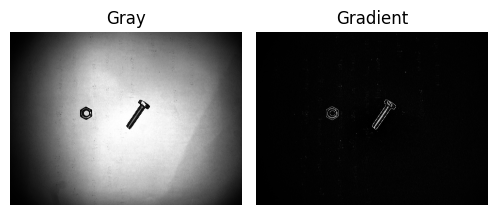

In [7]:
img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\test3\IMG_20260413_123042.jpg"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\gen\tpr.png"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\testing1\IMG_20260413_123010.jpg"
img=r"D:\tempv\New folder\20260514_190440.jpg.jpeg"
# img=r"C:\python\computer_vision\Image-based-dimension-measurement-\test_images\New folder\nut3.jpg"
img = cv2.imread(img)
# img=cv2.resize(img,(640,630))
gray, grad= best_edge_fix(img)


# 🔽 DISPLAY
plt.figure(figsize=(10,6))



plt.subplot(1,4,1)
plt.title("Gray")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Gradient")
plt.imshow(grad, cmap='gray')
plt.axis('off')



plt.tight_layout()
plt.show()

In [8]:
cv2.imwrite("f1.jpg",grad)
cv2.imwrite("f2.jpg",gray)

True

In [9]:
def get_outer_contour(edge_img, gray_img):

    # Binary
    _, edge = cv2.threshold(
        edge_img,
        15,
        255,
        cv2.THRESH_BINARY
    )

    # Close gaps in edge
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5,5)
    )

    edge = cv2.morphologyEx(
        edge,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Fill from contour
    contours, _ = cv2.findContours(
        edge,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if not contours:
        return None, None, gray_img

    cnt = max(contours, key=cv2.contourArea)

    # Fill object
    mask = np.zeros_like(edge)

    cv2.drawContours(
        mask,
        [cnt],
        -1,
        255,
        -1
    )

    # Smooth mask and remove side artifacts
    kernel2 = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (11,11)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel2
    )

    # Extract contour again from cleaned mask
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    cnt = max(contours, key=cv2.contourArea)

    out = cv2.cvtColor(
        gray_img,
        cv2.COLOR_GRAY2BGR
    )

    cv2.drawContours(
        out,
        [cnt],
        -1,
        (0,255,0),
        2
    )

    return cnt, mask, out

True

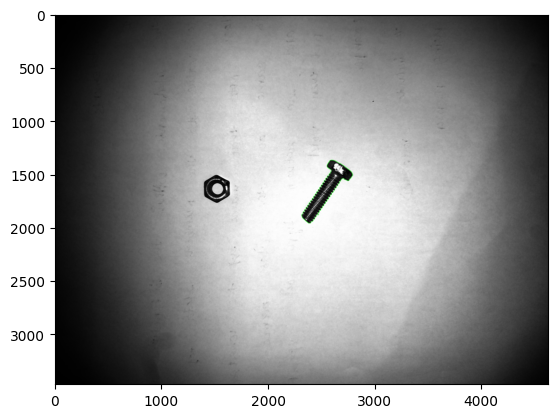

In [10]:
cntr, mask, result = get_outer_contour(grad, gray)
# re,rt,uu=draw_nut_outline(gray)
plt.imshow(result)
cv2.imwrite("wasted.png",mask)

In [3]:


model = YOLO(
    r"C:\python\computer_vision\Image-based-dimension-measurement-\model\yolo_bolt_nut_seg_best.pt"
)
model.names

{0: 'bolt', 1: 'nut'}

In [12]:

def detect_expand_box(img, expand=0.20):

    results = model(
        img,
        device=0,
        conf=0.5,
        imgsz=640,
        half=True,
        verbose=True
    )

    for result in results:
        for box in result.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])

            w = x2 - x1
            h = y2 - y1

            # Expand 20%
            pad_w = int(w * expand * 0.5)
            pad_h = int(h * expand * 0.5)

            x1 = max(0, x1 - pad_w)
            y1 = max(0, y1 - pad_h)
            x2 = min(img.shape[1], x2 + pad_w)
            y2 = min(img.shape[0], y2 + pad_h)

            # Crop expanded image
            imgcrop = img[y1:y2, x1:x2]

            

            # Call your function directly
            if cls == 0:
                plt.imshow(imgcrop)
                # cv2.imwrite("cv.png",imgcrop)
                # gray,grad=best_edge_fix(imgcrop)
                # cntr, mask, result = get_outer_contour(grad, gray)
                # # plt.imshow(mask)
                return imgcrop

            elif cls == 1:
                gray,grad=best_edge_fix(imgcrop)
                cntr, mask, result = get_outer_contour(grad, gray)
                # return imgcrop

    # return img


0: 480x640 1 bolt, 1 nut, 205.5ms
Speed: 18.7ms preprocess, 205.5ms inference, 87.0ms postprocess per image at shape (1, 3, 480, 640)


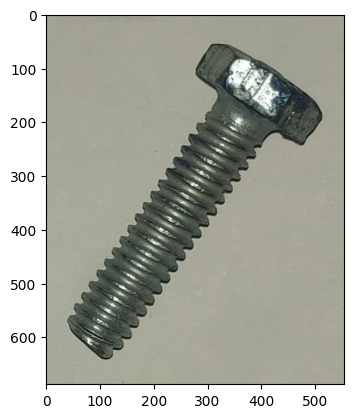

In [13]:
cc=detect_expand_box(img)
gray,grad=best_edge_fix(cc)
cntr, mask, result = get_outer_contour(grad, gray)

In [41]:
import cv2
import numpy as np

def rotate_contour_region(image, contour, angle):
    h, w = image.shape[:2]

    # Create white background
    result = np.full_like(image, 255)

    # Mask from contour
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, cv2.FILLED)

    # Extract object
    obj = cv2.bitwise_and(image, image, mask=mask)

    # Rotation matrix
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Rotate object and mask
    obj_rot = cv2.warpAffine(
        obj, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderValue=(0, 0, 0)
    )

    mask_rot = cv2.warpAffine(
        mask, M, (w, h),
        flags=cv2.INTER_NEAREST,
        borderValue=0
    )

    # Paste rotated object onto white background
    result[mask_rot > 0] = obj_rot[mask_rot > 0]

    return result

In [43]:
import cv2

def draw_measurement_lines(img, resultwidth, color=(0, 255, 0), thickness=2):
    top = resultwidth["top"]
    bottom = resultwidth["bottom"]

    # Vertical line positions
    x_right_top = int(top["center"][0] + top["width"] / 1.5)
    x_right_bottom = int(bottom["center"][0] + bottom["width"] / 1.5)

    # Use average so line is straight
    x = int((x_right_top + x_right_bottom) / 2)

    y_top = top["center"][1]
    y_bottom = bottom["center"][1]

    # Main vertical line
    cv2.line(img, (x, y_top), (x, y_bottom), color, thickness)

    # Horizontal line above top by 10% of top width
    offset_top = int(top["width"] * 0.10)
    y_top_h = y_top - offset_top

    cv2.line(
        img,
        (top["right"][0], y_top_h),
        (x, y_top_h),
        color,
        thickness
    )

    # Horizontal line below bottom by 10% of bottom width
    offset_bottom = int(bottom["width"] * 0.10)
    y_bottom_h = y_bottom + offset_bottom

    cv2.line(
        img,
        (bottom["right"][0], y_bottom_h),
        (x, y_bottom_h),
        color,
        thickness
    )

    return img

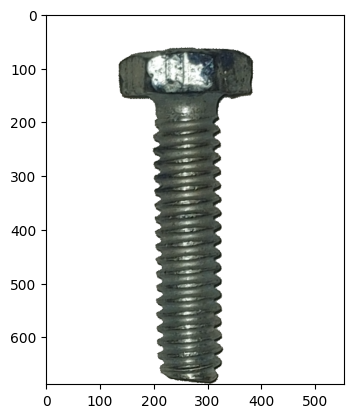

In [42]:


from texture_process_module_3 import create_largest_contour_mask,find_best_rotation

a,b,c=create_largest_contour_mask(cc)

best_mask, angle, height, mask_top_bottom, center,upside_down = find_best_rotation(a)
nsw=rotate_contour_region(b,c, angle)
plt.imshow(nsw)



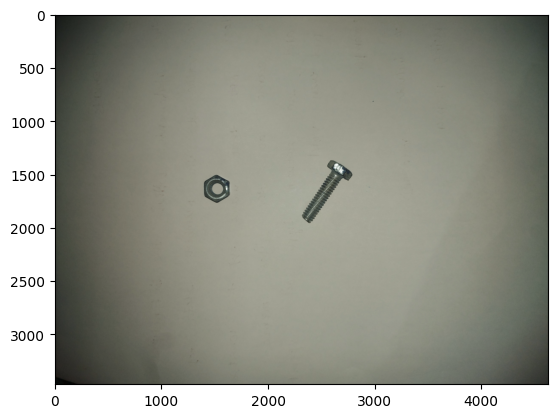

In [14]:
plt.imshow(img)

In [15]:
def create_largest_contour_mask(img):
    """
    Create a filled white mask from the largest contour.

    Args:
        cc : Input BGR image

    Returns:
        mask : White-filled largest contour mask
        masked_result : Original image with mask applied
        largest : Largest contour
    """

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Blur slightly
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold
    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None, None, None

    # Largest contour
    largest = max(contours, key=cv2.contourArea)

    # Create black mask
    mask = np.zeros(gray.shape, dtype=np.uint8)

    # Fill contour with white
    cv2.drawContours(
        mask,
        [largest],
        -1,
        255,
        thickness=-1
    )

    # Apply mask
    masked_result = cv2.bitwise_and(img, img, mask=mask)

    return mask, masked_result, largest


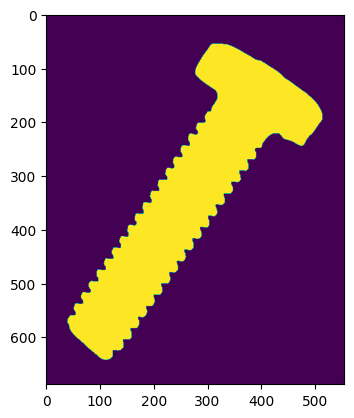

In [16]:
ms,msr,lr=create_largest_contour_mask(cc)
plt.imshow(ms)

In [17]:
cen=get_centroid(ms)
best_mask, angle, height,mask_top_bottom ,center= find_best_rotation(ms)

In [18]:
angle

-52.9434700012207

In [19]:
mask_list = [list(row) for row in mask_top_bottom]

# Perform your assignment
mask_list[0][0], mask_list[1][0] = 277, 277

# Convert back to a tuple if strictly required
mask_top_bottom = tuple(tuple(row) for row in mask_list)


mask_top_bottom

((277, 192), (277, 442))

True

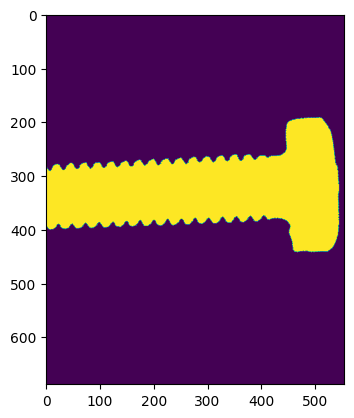

In [20]:
plt.imshow(best_mask)
cv2.imwrite("img1.png",best_mask)

In [21]:


h, w = ms.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, angle, 1.0)

rotated_mask = cv2.warpAffine(
    ms,
    M,
    (w, h),
    flags=cv2.INTER_NEAREST,
    borderValue=0
)
# cv2.line(rotated_mask, *mask_top_bottom, (0,0,0), 2)
# plt.imshow(rotated_mask, cmap='gray')
# plt.axis("off")
# plt.show()

# cv2.imwrite("img2.png",rotated_mask)

In [22]:
m1 = (rotated_mask > 0).astype(np.uint8)
m2 = (best_mask > 0).astype(np.uint8)

# Make sure both masks have same shape
if m1.shape != m2.shape:
    m2 = cv2.resize(
        m2,
        (m1.shape[1], m1.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

# IoU match %
intersection = np.logical_and(m1, m2).sum()
union = np.logical_or(m1, m2).sum()

match_percent = (intersection / union) * 100 if union > 0 else 0

print(f"Match: {match_percent:.2f}%")

Match: 86.17%


In [23]:
top_point, bottom_point = mask_top_bottom

cv2.circle(best_mask, top_point, 4, (0,0,0), 3)
cv2.circle(best_mask, bottom_point, 4, (0,0,0), 3)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [25]:
data={'top': {'center': (692, 323), 'width': 165, 'left': (610, 323), 'right': (775, 323)}, 
 'center': {'center': (693, 464), 'width': 79, 'left': (654, 464), 'right': (733, 464)}, 
 'bottom': {'center': (696, 654), 'width': 77, 'left': (658, 654), 'right': (735, 654)}}

In [26]:
for i in data.keys():
    print(data[i]['width'])

165
79
77


In [27]:
{
     "fixed_bolt_height":number,"thread_height":num,"top widht":val,"center with":val,"bottom width":val
}

NameError: name 'number' is not defined